In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from task_decomposition.analysis.comparisons import (get_subtask_similarity,
                                                    #  get_IOU,
                                                    #  get_semantic_distance,
                                                     extract_subtask_from_groundtruth_file,
                                                    #  extract_subtask_from_LLM_output_file,
                                                     extract_subtask_from_annotation_file,
                                                     extract_user_from_annotation_file,
                                                    #  extract_timespent_from_annotation_file
                                                    )
# from task_decomposition.utils.random_subtask_decomposition import get_random_subtask_decomposition
from task_decomposition.paths import (ROBOT_TRAJ_GROUNDTRUTH_DATA_PATH, 
                                      LLM_OUTPUT_PATH,
                                    # ANNOTATION_PATH,
                                      # SAVE_PLOTS_PATH,
                                      # BASELINES_DATA
                                      )
from task_decomposition.constants import (START_STEP_IDX, 
                                          # END_STEP_IDX, 
                                          # DESCRIPTION_IDX, 
                                          ENVIRONMENT_NAMES)

In [6]:
def _get_filepaths(env_name: str, 
                   llm_model: str, 
                   input_mode: str,  
                   kind:str, 
                   in_context: bool) -> list:
    """
    Get the list of groundtruth or LLM output filepaths for a given environment
    """
    if kind == "groundtruth":
        files_path = ROBOT_TRAJ_GROUNDTRUTH_DATA_PATH(env_name)
    elif kind == "llm_output":
        files_path = LLM_OUTPUT_PATH(llm_model=llm_model, 
                                     input_mode=input_mode, 
                                     env_name=env_name,
                                     in_context=in_context)
    else:
        raise ValueError(f"Invalid kind {kind}. Must be either 'groundtruth' or 'llm_outputs'.")
    files = os.listdir(files_path)
    files.remove(".gitkeep") if ".gitkeep" in files else None
    files.remove(".DS_Store") if ".DS_Store" in files else None
    files = [os.path.join(files_path, file) for file in files]
    files = sorted(files)
    return files

### Plot Annotations

In [15]:
# Find out who is the most similar to the groundtruth
# There is one human annotation file per ground truth file

# Loop through all ground truth files and find the most similar human annotation file
output = {}
for env_name in ENVIRONMENT_NAMES:
    print(f"Environment: {env_name}")
    gt_files = _get_filepaths(
        env_name=env_name,
        llm_model=None,
        input_mode=None,
        in_context=None,
        kind="groundtruth",
    )
    # print(f"Env: {env_name}")
    n_runs = len(gt_files)
    groundtruth_annotation = {
        "runid": np.full(n_runs, np.nan),
        "user": np.full(n_runs, np.nan),
        "semantic": np.full(n_runs, np.nan),
        "temporal": np.full(n_runs, np.nan),
    }
    output[env_name] = {"temporal": np.full(n_runs, np.nan), 
                        "semantic": np.full(n_runs, np.nan),
                        "user": np.full(n_runs, None)}

    for idx, gt_file in enumerate(gt_files):
        gt_subtask_decomposition = extract_subtask_from_groundtruth_file(gt_file)

        runid = gt_file.split("/")[-1].split("_gt")[0]
        annotation_subtask_decomposition = extract_subtask_from_annotation_file(
            runid=runid
        )
        annotation_user = extract_user_from_annotation_file(runid=runid)

        # compare the subtasks
        try:
            similarity = get_subtask_similarity(
                gt_subtask_decomposition, annotation_subtask_decomposition
            )
        except Exception as e:
            print(f" Error with {runid}: {e}")
            continue
        output[env_name]["temporal"][idx] = similarity["temporal"]
        output[env_name]["semantic"][idx] = similarity["semantic"]
        output[env_name]["user"][idx] = annotation_user
        # output[env_name]["total"][idx] = similarity["total"]
        # if verbose:
        #     print(f"{gt_runid} and {llm_runid}")
        #     print(f" Temporal: {similarity['temporal']:.2f} | Semantic: {similarity['semantic']:.2f}")

    # Clean the output in case nans are present
    output[env_name]["temporal"] = output[env_name]["temporal"][~np.isnan(output[env_name]["temporal"])]
    output[env_name]["semantic"] = output[env_name]["semantic"][~np.isnan(output[env_name]["semantic"])]
    # output[env_name]["total"] = output[env_name]["total"][~np.isnan(output[env_name]["total"])]

    # if SAVE_OUTPUT:
    #     np.savez(f"{ANNOTATION_PATH}/{env_name}_results.npz", **output)

    # print(f"  Number of runs: {n_runs}, Number of valid runs: {len(output[env_name]['temporal'])}")
    # print(
    #     f"  Temporal: {np.mean(output[env_name]['temporal']):.2f}+/-{np.std(output[env_name]['temporal']):.2f} |  Semantic: {np.mean(output[env_name]['semantic']):.2f}+/-{np.std(output[env_name]['semantic']):.2f}"
    # )

Environment: Door
Environment: Lift
Environment: PickPlace
 Error with PickPlace_20240220-222624_13: Invalid subtask: start index after end index
Environment: Stack


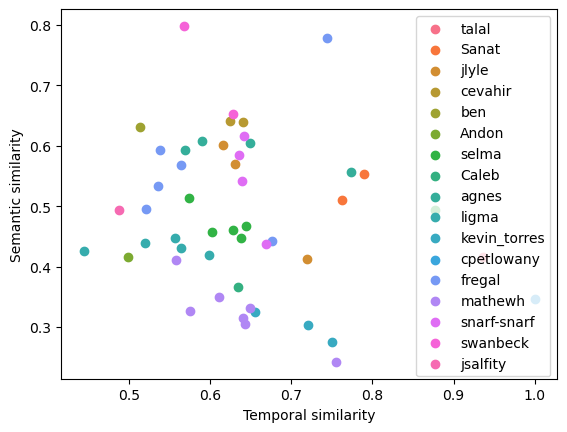

In [22]:
# Drop the following data points from the analysis
users_to_drop = ['cevahir', 'ligma', 'snarf-snarf', 'jsalfity']
# grad_students = ['selma', '', 'jsalfity', 'ligma', 'cevahir', '' ]

output['Door']
temporal = output['Door']['temporal']
semantic = output['Door']['semantic']
user = output['Door']['user']

# # Drop the users to drop
mask = np.ones(len(temporal), dtype=bool)
for u in users_to_drop:
    mask = mask & (user != u)
temporal = temporal[mask]
semantic = semantic[mask]
user = user[mask]

# Scatter plot with color per user
plt.figure()
colors = sns.color_palette("husl", len(set(user)))
for idx, u in enumerate(set(user)):
    mask = user == u
    plt.scatter(temporal[mask], semantic[mask], c=[colors[idx]], label=u)
plt.xlabel("Temporal similarity")
plt.ylabel("Semantic similarity")
plt.legend()
